# Chapter 3. 특정 작업을 잘하도록 비전 언어 모델 파인튜닝하기

## 3.2. 데이터셋 준비

### 3.2.1. LaTeX OCR 데이터셋 소개

In [1]:
!pip list | grep torch

torch                                    2.9.0+cu126
torchao                                  0.10.0
torchaudio                               2.9.0+cu126
torchdata                                0.11.0
torchsummary                             1.5.1
torchtune                                0.6.1
torchvision                              0.24.0+cu126


In [2]:
!pip install -q -U trl num2words bitsandbytes>=0.46.1

In [3]:
!pip install -q flash-attn --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 173.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
from datasets import load_dataset

dataset = load_dataset("unsloth/LaTeX_OCR")
dataset

README.md:   0%|          | 0.00/519 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7632 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 68686
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 7632
    })
})

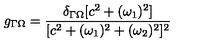

In [7]:
sample = dataset['train'][100]
sample_image = sample['image']
sample_image

In [8]:
sample_text = sample['text']
sample_text

'g _ { \\Gamma \\Omega } = { \\frac { \\delta _ { \\Gamma \\Omega } [ c ^ { 2 } + ( \\omega _ { 1 } ) ^ { 2 } ] } { [ c ^ { 2 } + ( \\omega _ { 1 } ) ^ { 2 } + ( \\omega _ { 2 } ) ^ { 2 } ] ^ { 2 } } }'

### 3.2.2. 파인튜닝용 데이터 형식으로 변환

In [9]:
def format_data(sample):
   return {
       "images": [sample['image']],
       "messages": [
           {
               "role": "user",
               "content": [
                   {
                       "type": "text",
                       "text": "Convert the equation images to LaTeX equations."
                   },
                   {
                       "type": "image"
                   }
               ]
           },
           {
               "role": "assistant",
               "content": [
                   {
                       "type": "text",
                       "text": sample['text']
                   }
               ]
           }
       ]
   }

### 3.2.3. 학습 및 평가 데이터 분할

In [10]:
from datasets import load_dataset

train_dataset, eval_dataset = load_dataset(
   "unsloth/LaTeX_OCR",
   split=["train[:5%]", "test[:5%]"]
)

print(f"훈련 샘플 수: {len(train_dataset)}")
print(f"평가 샘플 수: {len(eval_dataset)}")

훈련 샘플 수: 3434
평가 샘플 수: 382


In [11]:
train_dataset = [format_data(sample) for sample in train_dataset]
eval_dataset = [format_data(sample) for sample in eval_dataset]

In [12]:
train_dataset[0]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>],
 'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Convert the equation images to LaTeX equations.'},
    {'type': 'image'}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}]}]}

## 3.3. 기존 모델의 성능 확인

### 3.3.1. 모델과 프로세서 불러오기

In [16]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

model_id = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"

model = AutoModelForImageTextToText.from_pretrained(
   model_id,
   dtype=torch.bfloat16,
   device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_id)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

### 3.3.2. 기존 모델로 추론하기

In [17]:
messages = [
   {
       "role": "user",
       "content": [
           {
               "type": "text",
               "text": "Convert the equation images to LaTeX equations."
           },
           {
               "type": "image"
           },
       ]
   }
]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(images=sample_image, text=prompt, return_tensors="pt").to(device=model.device, dtype=model.dtype)

generated_ids = model.generate(**inputs, max_new_tokens=256)
input_len = inputs["input_ids"].shape[-1]
output_ids = generated_ids[:, input_len:]

generated_text = processor.decode(output_ids[0], skip_special_tokens=True)

### 3.3.3. 결과 분석

In [19]:
print("정답 LaTeX:")
print(sample_text)
print("\n" + "=" * 50)
print("SmolVLM2 출력:")
print(generated_text)

정답 LaTeX:
g _ { \Gamma \Omega } = { \frac { \delta _ { \Gamma \Omega } [ c ^ { 2 } + ( \omega _ { 1 } ) ^ { 2 } ] } { [ c ^ { 2 } + ( \omega _ { 1 } ) ^ { 2 } + ( \omega _ { 2 } ) ^ { 2 } ] ^ { 2 } } }

SmolVLM2 출력:
 \begin{align*}
g_{\pi} &= \frac{\delta_{\pi}[c^{2} + (\omega_{1})^{2} + (\omega_{2})^{2}]}{[c^{2} + (\omega_{1})^{2} + (\omega_{2})^{2}]^{2}}
\end{align*}


## 3.4. 모델 파인튜닝

### 3.4.2. 양자화된 모델 불러오기

In [20]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

model_id = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"

bnb_config = BitsAndBytesConfig(
   load_in_4bit=True,
   bnb_4bit_use_double_quant=True,
   bnb_4bit_quant_type="nf4",
   bnb_4bit_compute_dtype=torch.bfloat16
)

model = AutoModelForImageTextToText.from_pretrained(
   model_id,
   dtype="auto",
   quantization_config=bnb_config,
   attn_implementation="flash_attention_2",
   device_map="auto",
)

processor = AutoProcessor.from_pretrained(model_id)

Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in SmolVLMForConditionalGeneration is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", dtype=torch.float16)`
Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in SmolVLMModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", dtype=torch.float16)`
You are attempting to use Flash Attention 2 without specifying a torch dtype. This might lead to 

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

### 3.4.3. LoRA 어댑터 설정

In [21]:
from peft import LoraConfig

# LoRA 설정
peft_config = LoraConfig(
   r=8,
   lora_alpha=16,
   lora_dropout=0.05,
   target_modules=[
       'q_proj',
       'k_proj',
       'v_proj',
       'o_proj',
       'gate_proj',
       'up_proj',
       'down_proj',
   ],
)

### 3.4.4. 학습 설정 및 Data Collator

In [22]:
from trl import SFTConfig

training_args = SFTConfig(
   output_dir="smolvlm2-trl-sft-latexocr",
   num_train_epochs=1,
   per_device_train_batch_size=1,
   gradient_accumulation_steps=4,
   gradient_checkpointing=True,
   optim='adamw_8bit',
   learning_rate=2e-4,
   warmup_steps=10,
   weight_decay=0.01,
   bf16=True,
   logging_steps=200,
   save_strategy='steps',
   save_steps=200,
   save_total_limit=2,
   report_to='none',
   remove_unused_columns=False,
   dataset_text_field='',
   dataset_kwargs={'skip_prepare_dataset': True},
)

In [23]:
def collate_fn(samples):
   texts = []
   images = []
   for sample in samples:
       image_inputs = sample["images"]
       text = processor.apply_chat_template(
           sample["messages"],
           add_generation_prompt=False,
           tokenize=False
       )
       texts.append(text.strip())
       images.append(image_inputs)

   # 텍스트와 이미지를 함께 처리
   batch = processor(text=texts, images=images, return_tensors="pt", padding=True)

   # 레이블 생성 (입력과 동일하지만 패딩과 이미지 토큰은 마스킹)
   labels = batch["input_ids"].clone()

   # 이미지 토큰과 특수 토큰 마스킹
   image_token_id = processor.tokenizer.convert_tokens_to_ids(processor.image_token)
   fake_image_token_id = processor.tokenizer.convert_tokens_to_ids(
       processor.tokenizer.special_tokens_map["fake_image_token"]
   )

   labels[labels == processor.tokenizer.pad_token_id] = -100
   labels[labels == image_token_id] = -100
   labels[labels == fake_image_token_id] = -100

   batch["labels"] = labels
   return batch

### 3.4.5. SFTTrainer로 학습 시작

In [25]:
from trl import SFTTrainer

trainer = SFTTrainer(
   model=model,
   args=training_args,
   train_dataset=train_dataset,
   peft_config=peft_config,
   processing_class=processor,
   data_collator=collate_fn,
)

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [26]:
trainer.model.print_trainable_parameters()

trainable params: 10,536,960 || all params: 2,257,321,840 || trainable%: 0.4668


In [ ]:
trainer.train()

trainer.save_model(training_args.output_dir)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 49279, 'bos_token_id': 1, 'pad_token_id': 2}.
Casting fp32 inputs back to torch.bfloat16 for flash-attn compatibility.


Step,Training Loss
200,0.338509
400,0.147114
600,0.123724
800,0.106430


## 3.5. 파인튜닝 모델 확인

### 3.5.1. 파인튜닝된 모델 불러오기

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

model_id = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"

# 파인튜닝된 모델 로드
finetuned_model = AutoModelForImageTextToText.from_pretrained(
   training_args.output_dir,
   dtype="auto",
   device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_id)

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/498 [00:00<?, ?it/s]

### 3.5.2. 테스트 샘플로 평가

정답 LaTeX:
\delta _ { \Lambda } C = d \Lambda \ ,


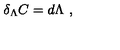

In [ ]:
test_sample = eval_dataset[40]
test_image = test_sample['images']
test_answer = test_sample['messages'][1]['content'][0]['text']

print("정답 LaTeX:")
print(test_answer)
test_image[0]

In [ ]:
# 베이스라인 모델 로드
baseline_model = AutoModelForImageTextToText.from_pretrained(
   model_id,
   dtype="auto",
   device_map="auto"
)

messages = [
   {
       "role": "user",
       "content": [
           {"type": "image"},
           {"type": "text", "text": "Convert the equation images to LaTeX equations."}
       ]
   }
]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

In [ ]:
inputs = processor(images=test_image[0], text=prompt, return_tensors="pt").to(baseline_model.device)

generated_ids = baseline_model.generate(**inputs, max_new_tokens=512)
input_len = inputs["input_ids"].shape[-1]
output_ids = generated_ids[:, input_len:]

baseline_output = processor.decode(output_ids[0], skip_special_tokens=True)

print("베이스라인 모델 출력:")
print(baseline_output)

베이스라인 모델 출력:
 \delta _ { C } = d \Delta ,


In [ ]:
inputs = processor(images=test_image[0], text=prompt, return_tensors="pt").to(finetuned_model.device)

generated_ids = finetuned_model.generate(**inputs, max_new_tokens=512)
input_len = inputs["input_ids"].shape[-1]
output_ids = generated_ids[:, input_len:]

finetuned_output = processor.decode(output_ids[0], skip_special_tokens=True)

print("파인튜닝 모델 출력:")
print(finetuned_output)

파인튜닝 모델 출력:
 \delta _ { \Lambda } C = d \Lambda \ ,


### 3.5.3. 결과 비교 및 분석

In [ ]:
from IPython.display import display, Latex

print("정답:")
display(Latex(test_answer))

print("\n 베이스라인 모델 출력:")
display(Latex(baseline_output))

print("\n 파인튜닝 모델 출력:")
display(Latex(finetuned_output))

정답:


<IPython.core.display.Latex object>


 베이스라인 모델 출력:


<IPython.core.display.Latex object>


 파인튜닝 모델 출력:


<IPython.core.display.Latex object>